# Determinantes

**Módulo:** 03 – Progressões, Matrizes e Sistemas Lineares

**Pré-requisitos:** [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb) (noção de matriz quadrada, matrizes especiais, produto de matrizes e a ideia intuitiva de matriz inversível).

**Objetivos de aprendizagem:**
- Calcular determinantes de matrizes de ordem até 3 (incluindo a Regra de Sarrus) e entender a ideia geral por trás do determinante de qualquer ordem.
- Aplicar o Teorema de Laplace e a Regra de Chió para calcular determinantes de ordem maior.
- Usar as propriedades dos determinantes para simplificar cálculos antes de resolvê-los.
- Calcular a matriz inversa de uma matriz quadrada através da matriz adjunta.

**Tempo estimado:** 90 a 105 minutos

[![Abrir no Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leandrofreiredealmeida/curso_matematica_python/blob/main/03_progressoes_matrizes_e_sistemas_lineares/0305a_determinantes.ipynb)

📖 **Leitura complementar:** [Determinante](https://pt.wikipedia.org/wiki/Determinante)

## Uma pergunta de agrimensor

Imagine que você está demarcando um terreno em forma de paralelogramo. Você conhece as coordenadas dos dois vetores que saem de um dos cantos até os vizinhos mais próximos: u = (4, 1) e v = (1, 3), em centenas de metros. Não dá pra simplesmente "contar quadradinhos" com essa precisão — e também não faz sentido desenhar o terreno em escala numa folha só para medir a área.

Existe alguma forma de calcular essa área **direto das coordenadas**, sem desenhar nada?

A resposta está escondida dentro de um número que se calcula a partir de qualquer matriz quadrada: o **determinante**. E, de quebra, ele também vai responder a uma pergunta que ficou em aberto no notebook de Matrizes — como saber se uma matriz tem inversa, sem sair tentando na base da tentativa e erro.

In [1]:
import math

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import ipywidgets as widgets
from IPython.display import display

# Paleta de cores Nord
NORD_FUNDO = "#2E3440"
NORD_PAINEL = "#3B4252"
NORD_LINHA = "#4C566A"
NORD_TEXTO = "#ECEFF4"
NORD_TEXTO_SEC = "#D8DEE9"
COR_PONTO = "#88C0D0"
COR_DESTAQUE = "#A3BE8C"
COR_ALERTA = "#BF616A"
COR_SECUNDARIA = "#81A1C1"
COR_EXTRA = "#B48EAD"
COR_AVISO = "#EBCB8B"


def estilizar_eixo(ax) -> None:
    """Aplica o estilo Nord padrão a um eixo do matplotlib."""
    ax.set_facecolor(NORD_FUNDO)
    ax.tick_params(colors=NORD_TEXTO_SEC)
    for spine in ax.spines.values():
        spine.set_color(NORD_LINHA)
    ax.grid(color=NORD_LINHA, linewidth=0.5, alpha=0.5)


def desenhar_matriz(
    ax,
    matriz: np.ndarray,
    titulo: str = "",
    cor_fundo: str = NORD_PAINEL,
    destaque: list[tuple[int, int]] | None = None,
    cor_destaque: str = COR_PONTO,
) -> None:
    """Desenha uma matriz como uma grade de células com os valores escritos, no estilo Nord."""
    linhas, colunas = matriz.shape
    ax.set_facecolor(NORD_FUNDO)
    destaque = destaque or []
    for i in range(linhas):
        for j in range(colunas):
            cor_celula = cor_destaque if (i, j) in destaque else cor_fundo
            ax.add_patch(
                plt.Rectangle(
                    (j, linhas - 1 - i), 1, 1,
                    facecolor=cor_celula, edgecolor=NORD_LINHA, linewidth=1.2,
                )
            )
            ax.text(
                j + 0.5, linhas - 1 - i + 0.5, f"{matriz[i, j]:g}",
                ha="center", va="center", color=NORD_TEXTO, fontsize=12,
            )
    ax.set_xlim(0, colunas)
    ax.set_ylim(0, linhas)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_aspect("equal")
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=11)
    for spine in ax.spines.values():
        spine.set_visible(False)


def desenhar_paralelogramo(ax, u: np.ndarray, v: np.ndarray, cor: str = COR_PONTO) -> None:
    """Desenha o paralelogramo formado pelos vetores u e v a partir da origem, com a área sombreada."""
    origem = np.array([0, 0])
    vertices = np.array([origem, u, u + v, v])
    ax.fill(vertices[:, 0], vertices[:, 1], color=cor, alpha=0.35, edgecolor=cor, linewidth=2)
    ax.annotate("", xy=u, xytext=origem, arrowprops=dict(arrowstyle="->", color=NORD_TEXTO, lw=2))
    ax.annotate("", xy=v, xytext=origem, arrowprops=dict(arrowstyle="->", color=NORD_TEXTO, lw=2))
    ax.text(*(u * 1.1 + 0.05), "u", color=NORD_TEXTO, fontsize=12, ha="center", va="center")
    ax.text(*(v * 1.1 + 0.05), "v", color=NORD_TEXTO, fontsize=12, ha="center", va="center")

## 1. Determinante: um número que resume uma matriz quadrada

Para cada matriz quadrada A, existe um número real associado a ela, chamado **determinante de A** — indicado por det(A) ou por |A| (as barras verticais aqui não significam módulo). Esse número carrega informações importantes sobre a matriz:

- Se A é ou não **inversível** (a condição exata vem lá no fim deste notebook).
- Um fator de escala de **área** (em ordem 2) ou **volume** (em ordem 3) associado à transformação que a matriz representa.
- A **orientação** dessa transformação — se ela preserva ou inverte o sentido do espaço.

Voltando ao problema do agrimensor: os vetores u = (4, 1) e v = (1, 3) podem virar as colunas de uma matriz quadrada A. O determinante dessa matriz é exatamente a área do paralelogramo formado por u e v.

📌 **Notação:** o determinante de A é indicado por det(A) ou |A|. Diferente do módulo de um número, o determinante **pode ser negativo** — o sinal carrega informação sobre orientação, como você vai ver no exemplo abaixo.

In [ ]:
u = np.array([4, 1])
v = np.array([1, 3])
A = np.array([[4, 1], [1, 3]])  # colunas de A são os vetores u e v

determinante_A = np.linalg.det(A)
print(f"Vetor u = {u}, vetor v = {v}")
print(f"Matriz A (colunas u e v):\n{A}")
print(f"det(A) = {determinante_A:.2f}")

Vetor u = [4 1], vetor v = [1 3]
Matriz A (colunas u e v):
[[4 1]
 [1 3]]
det(A) = 11.00


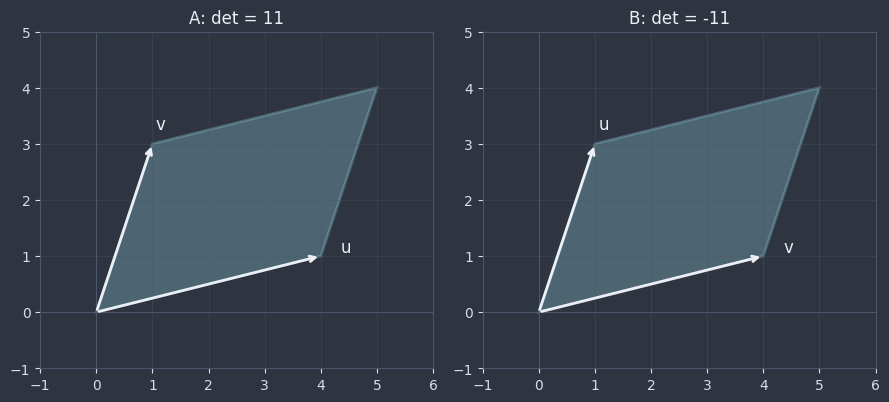

In [3]:
B = np.array([[1, 4], [3, 1]])  # mesmas colunas, ordem trocada: v e depois u
determinante_B = np.linalg.det(B)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(9, 4.5))
fig.patch.set_facecolor(NORD_FUNDO)
for ax, M, titulo in [(ax1, A, f"A: det = {determinante_A:.0f}"), (ax2, B, f"B: det = {determinante_B:.0f}")]:
    estilizar_eixo(ax)
    desenhar_paralelogramo(ax, M[:, 0], M[:, 1])
    ax.set_xlim(-1, 6)
    ax.set_ylim(-1, 5)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_title(titulo, color=NORD_TEXTO, fontsize=12)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()

**Pergunta de checagem:** as matrizes A e B do exemplo acima têm exatamente os mesmos vetores-coluna, só que em ordem trocada. Por que o paralelogramo desenhado é visualmente o mesmo, mas os determinantes têm sinais opostos? (Dica: pense no sentido — horário ou anti-horário — em que você percorre "primeiro u, depois v", comparado a "primeiro v, depois u".)

## 2. Determinante de ordem 1, 2 e 3

- **Ordem 1:** det([a]) = a — o determinante de uma matriz 1×1 é o próprio elemento.
- **Ordem 2:** det([[a, b], [c, d]]) = a·d − b·c — é exatamente a fórmula usada no Bloco 1.
- **Ordem 3:** calculada pela **Regra de Sarrus**.

A Regra de Sarrus funciona assim: repita as duas primeiras colunas da matriz à direita dela. Some os produtos das três diagonais que descem para a direita (↘) e subtraia os produtos das três diagonais que descem para a esquerda (↙).

Matriz M:
[[ 2 -1  3]
 [ 0  4  1]
 [ 5  2 -2]]
Regra de Sarrus: det(M) = -85
numpy.linalg.det: det(M) = -85.00


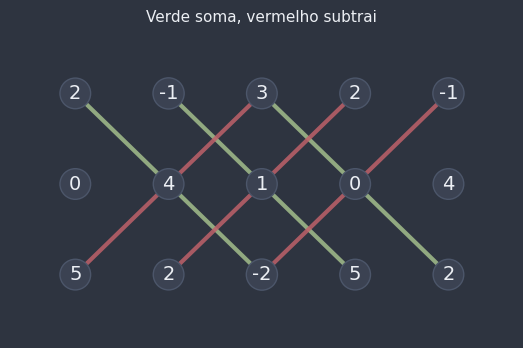

In [4]:
def determinante_sarrus(matriz: np.ndarray) -> float:
    """Calcula o determinante de uma matriz 3x3 pela Regra de Sarrus."""
    a, b, c = matriz[0]
    d, e, f = matriz[1]
    g, h, i = matriz[2]
    diagonais_positivas = a * e * i + b * f * g + c * d * h
    diagonais_negativas = c * e * g + a * f * h + b * d * i
    return diagonais_positivas - diagonais_negativas


def desenhar_sarrus(matriz: np.ndarray) -> None:
    """Desenha o diagrama clássico da Regra de Sarrus, com as diagonais positivas e negativas destacadas."""
    estendida = np.hstack([matriz, matriz[:, :2]])
    fig, ax = plt.subplots(figsize=(6.5, 4))
    fig.patch.set_facecolor(NORD_FUNDO)
    ax.set_facecolor(NORD_FUNDO)

    diagonais_positivas = [
        [(0, 0), (1, -1), (2, -2)],
        [(1, 0), (2, -1), (3, -2)],
        [(2, 0), (3, -1), (4, -2)],
    ]
    diagonais_negativas = [
        [(2, 0), (1, -1), (0, -2)],
        [(3, 0), (2, -1), (1, -2)],
        [(4, 0), (3, -1), (2, -2)],
    ]
    for diagonal in diagonais_positivas:
        xs, ys = zip(*diagonal)
        ax.plot(xs, ys, color=COR_DESTAQUE, linewidth=3, alpha=0.85, zorder=1)
    for diagonal in diagonais_negativas:
        xs, ys = zip(*diagonal)
        ax.plot(xs, ys, color=COR_ALERTA, linewidth=3, alpha=0.85, zorder=1)

    for linha in range(3):
        for coluna in range(5):
            ax.text(
                coluna, -linha, f"{estendida[linha, coluna]:g}",
                ha="center", va="center", color=NORD_TEXTO, fontsize=14, zorder=2,
                bbox=dict(boxstyle="circle", facecolor=NORD_PAINEL, edgecolor=NORD_LINHA),
            )
    ax.set_xlim(-0.7, 4.7)
    ax.set_ylim(-2.7, 0.7)
    ax.axis("off")
    ax.set_title("Verde soma, vermelho subtrai", color=NORD_TEXTO, fontsize=11)
    plt.show()


M = np.array([[2, -1, 3], [0, 4, 1], [5, 2, -2]])
det_sarrus = determinante_sarrus(M)
det_numpy = np.linalg.det(M)
print(f"Matriz M:\n{M}")
print(f"Regra de Sarrus: det(M) = {det_sarrus}")
print(f"numpy.linalg.det: det(M) = {det_numpy:.2f}")

desenhar_sarrus(M)

⚠️ **Erro comum:** a Regra de Sarrus **só vale para matrizes de ordem 3**. Não existe uma versão de "repetir colunas e cruzar diagonais" para ordem 4 ou maior — tentar generalizar direto essa ideia dá resultado errado. Para ordem 4 em diante, o caminho é outro: cofatores e o Teorema de Laplace, que vêm a seguir.

🕹️ **Widget interativo:** mexa nos sliders a, b, c, d de uma matriz 2×2 e veja o determinante — e a área do paralelogramo correspondente — sendo recalculados em tempo real.

In [ ]:
def mostrar_determinante_2x2(a: float, b: float, c: float, d: float) -> None:
    determinante = a * d - b * c
    fig, ax = plt.subplots(figsize=(5, 5))
    fig.patch.set_facecolor(NORD_FUNDO)
    estilizar_eixo(ax)
    cor = COR_DESTAQUE if determinante >= 0 else COR_ALERTA
    desenhar_paralelogramo(ax, np.array([a, c]), np.array([b, d]), cor=cor)
    limite = max(abs(a) + abs(b), abs(c) + abs(d), 1) + 1
    ax.set_xlim(-limite, limite)
    ax.set_ylim(-limite, limite)
    ax.axhline(0, color=NORD_LINHA, linewidth=0.8)
    ax.axvline(0, color=NORD_LINHA, linewidth=0.8)
    ax.set_aspect("equal")
    ax.set_title(f"det = {determinante:.2f}     área = {abs(determinante):.2f}", color=NORD_TEXTO, fontsize=12)
    plt.show()


widgets.interact(
    mostrar_determinante_2x2,
    a=widgets.FloatSlider(value=4, min=-5, max=5, step=0.5, description="a:"),
    b=widgets.FloatSlider(value=1, min=-5, max=5, step=0.5, description="b:"),
    c=widgets.FloatSlider(value=1, min=-5, max=5, step=0.5, description="c:"),
    d=widgets.FloatSlider(value=3, min=-5, max=5, step=0.5, description="d:"),
)

interactive(children=(FloatSlider(value=4.0, description='a:', max=5.0, min=-5.0, step=0.5), FloatSlider(value…

<function __main__.mostrar_determinante_2x2(a: float, b: float, c: float, d: float) -> None>

**Pergunta de checagem:** existe alguma combinação dos sliders a, b, c, d (diferente de todos nulos) para a qual o paralelogramo "desaparece" — vira só um segmento de reta, sem área? O que acontece com o determinante nesse caso?

## 3. Menor complementar e complementar algébrico

Antes de generalizar o determinante para qualquer ordem, precisamos de duas definições auxiliares, sempre relativas a um elemento a_ij de uma matriz quadrada A:

- **Menor complementar** D_ij: o determinante da matriz que sobra ao eliminar a linha i e a coluna j de A.
- **Complementar algébrico** (ou **cofator**) A_ij: o menor complementar com um sinal aplicado, A_ij = (−1)^(i+j) · D_ij.

📌 **Definições lado a lado:**
- D_ij = det(A sem a linha i e sem a coluna j)
- A_ij = (−1)^(i+j) · D_ij

💡 **Dica:** o padrão de sinais (−1)^(i+j) forma um "tabuleiro de xadrez" — a posição (1,1) é sempre "+", e os sinais alternam a cada casa vizinha (+, −, +, −, ...). Memorizar essa imagem mental evita erro de sinal na hora de calcular um cofator.

In [6]:
def menor_complementar(matriz: np.ndarray, i: int, j: int) -> float:
    """Determinante da matriz obtida eliminando a linha i e a coluna j de matriz."""
    submatriz = np.delete(np.delete(matriz, i, axis=0), j, axis=1)
    return np.linalg.det(submatriz)


def cofator(matriz: np.ndarray, i: int, j: int) -> float:
    """Complementar algébrico (cofator) do elemento na linha i, coluna j de matriz."""
    return ((-1) ** (i + j)) * menor_complementar(matriz, i, j)


N = np.array([[1, 2, 3], [4, 5, 6], [7, 8, 10]])

# Menor complementar e cofator do elemento a_12 (linha 1, coluna 2 -> indices 0 e 1)
D_12 = menor_complementar(N, 0, 1)
A_12 = cofator(N, 0, 1)
print(f"Matriz N:\n{N}")
print(f"Menor complementar D_12 (remove linha 1, coluna 2) = {D_12:.0f}")
print(f"Complementar algébrico A_12 = (-1)^(1+2) * D_12 = {A_12:.0f}")

Matriz N:
[[ 1  2  3]
 [ 4  5  6]
 [ 7  8 10]]
Menor complementar D_12 (remove linha 1, coluna 2) = -2
Complementar algébrico A_12 = (-1)^(1+2) * D_12 = 2


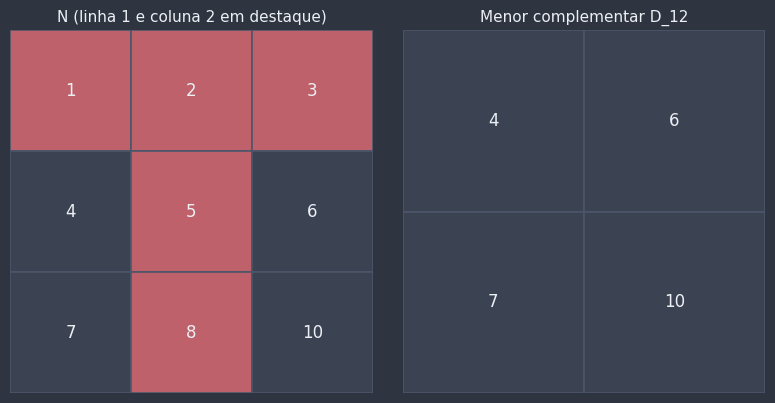

In [7]:
menor_01 = np.delete(np.delete(N, 0, axis=0), 1, axis=1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 4))
fig.patch.set_facecolor(NORD_FUNDO)
desenhar_matriz(
    ax1, N, titulo="N (linha 1 e coluna 2 em destaque)",
    destaque=[(0, j) for j in range(3)] + [(i, 1) for i in range(3)], cor_destaque=COR_ALERTA,
)
desenhar_matriz(ax2, menor_01, titulo="Menor complementar D_12")
plt.tight_layout()
plt.show()

**Pergunta de checagem:** o menor complementar D_21 (eliminar a linha 2 e a coluna 1 de N) é o determinante de qual submatriz 2×2? Ele tem o mesmo valor de D_12? E o cofator A_21 tem o mesmo sinal de A_12?

## 4. Determinante de qualquer ordem — definição por cofatores

Com menor complementar e cofator em mãos, dá para definir o determinante de uma matriz quadrada de **qualquer ordem** n, não só até 3: o determinante é a soma dos produtos dos elementos de uma linha (ou coluna) pelos seus respectivos cofatores.

Para a primeira linha, por exemplo:

det(A) = a_11 · A_11 + a_12 · A_12 + ... + a_1n · A_1n

Essa definição é **recursiva**: para calcular A_1j (um cofator), é preciso calcular o determinante de uma matriz (n−1) × (n−1) — que, por sua vez, pode ser calculado do mesmo jeito, até chegar numa matriz 1×1 (cujo determinante já sabemos: é o próprio elemento). É essa recursão que permite calcular o determinante de uma matriz 4×4, 5×5, ou de qualquer tamanho.

In [8]:
def determinante_por_cofatores(matriz: np.ndarray) -> float:
    """Calcula o determinante de qualquer matriz quadrada, expandindo recursivamente pela primeira linha."""
    n = matriz.shape[0]
    if n == 1:
        return matriz[0, 0]
    total = 0.0
    for coluna in range(n):
        elemento = matriz[0, coluna]
        if elemento == 0:
            continue
        submatriz = np.delete(np.delete(matriz, 0, axis=0), coluna, axis=1)
        total += elemento * ((-1) ** coluna) * determinante_por_cofatores(submatriz)
    return total


P = np.array([[2, 0, 1, 0], [1, 4, 0, 2], [0, 3, 5, 1], [2, 1, 0, 4]])

det_cofatores = determinante_por_cofatores(P)
det_numpy = np.linalg.det(P)
print(f"Matriz P (4x4):\n{P}")
print(f"Determinante por cofatores (recursivo) = {det_cofatores:.2f}")
print(f"numpy.linalg.det = {det_numpy:.2f}")

Matriz P (4x4):
[[2 0 1 0]
 [1 4 0 2]
 [0 3 5 1]
 [2 1 0 4]]
Determinante por cofatores (recursivo) = 147.00
numpy.linalg.det = 147.00


**Pergunta de checagem:** a função `determinante_por_cofatores` para (caso-base) quando a matriz é 1×1. Por que esse é um bom caso-base — e o que aconteceria se a função tentasse continuar reduzindo a ordem além disso?

## 5. Teorema de Laplace

A definição do Bloco 4 usou sempre a **primeira linha**. Mas o resultado não depende dessa escolha:

📌 **Teorema de Laplace:** o determinante de uma matriz quadrada pode ser calculado expandindo por **qualquer linha ou qualquer coluna** — o resultado é sempre o mesmo.

Isso quer dizer que, na hora de calcular um determinante na mão, você pode escolher a linha ou coluna mais conveniente.

In [9]:
def determinante_por_cofatores(matriz: np.ndarray, linha: int = 0) -> float:
    """Generalização do Bloco 4: expande pela linha escolhida, não só pela primeira (Teorema de Laplace)."""
    n = matriz.shape[0]
    if n == 1:
        return matriz[0, 0]
    total = 0.0
    for coluna in range(n):
        elemento = matriz[linha, coluna]
        if elemento == 0:
            continue
        submatriz = np.delete(np.delete(matriz, linha, axis=0), coluna, axis=1)
        total += elemento * ((-1) ** (linha + coluna)) * determinante_por_cofatores(submatriz)
    return total


det_linha_0 = determinante_por_cofatores(P, linha=0)
det_linha_2 = determinante_por_cofatores(P, linha=2)
print(f"Expandindo pela linha 1 (índice 0): det(P) = {det_linha_0:.2f}")
print(f"Expandindo pela linha 3 (índice 2): det(P) = {det_linha_2:.2f}")
print(f"Os dois resultados batem? {np.isclose(det_linha_0, det_linha_2)}")

Expandindo pela linha 1 (índice 0): det(P) = 147.00
Expandindo pela linha 3 (índice 2): det(P) = 147.00
Os dois resultados batem? True


💡 **Dica:** sempre que for calcular um determinante à mão, escolha a linha ou coluna com **mais zeros** para expandir — cada zero elimina um termo inteiro da soma, economizando contas. Foi por isso que a linha 1 de P (com dois zeros) foi a escolhida no Bloco 4.

<details>
<summary>🕵️ Aprofundamento (opcional): esboço da demonstração do Teorema de Laplace</summary>

A demonstração completa é por indução na ordem n da matriz:

- **Caso base (n = 1 ou n = 2):** para matrizes 1×1 e 2×2, a fórmula do determinante já expande "por qualquer linha ou coluna" trivialmente — são poucos termos para conferir à mão.
- **Passo indutivo:** supondo que o teorema vale para todas as matrizes de ordem n−1 (ou seja, que o determinante de qualquer menor complementar não depende da linha/coluna escolhida para expandi-lo), mostra-se que a expansão de uma matriz de ordem n por duas linhas diferentes leva à mesma soma de termos — só reorganizados de forma diferente. A manipulação algébrica é longa (envolve reagrupar somatórios duplos), mas a ideia central é: como cada menor complementar já "não liga" para a linha/coluna escolhida internamente (hipótese de indução), o resultado final também não liga para a linha/coluna escolhida na matriz de ordem n.

Para a demonstração completa, formal, veja a seção correspondente no verbete em inglês da Wikipédia, [Determinant](https://en.wikipedia.org/wiki/Determinant).

</details>

📖 **Leitura complementar:** [Teorema de Laplace](https://pt.wikipedia.org/wiki/Teorema_de_Laplace)

## 6. Propriedades dos determinantes

Algumas propriedades ajudam a simplificar (ou até evitar) contas na hora de calcular um determinante. Todas podem ser verificadas numericamente:

In [10]:
Q = np.array([[1, 2, 3], [0, 1, 4], [5, 6, 0]], dtype=float)
print(f"det(Q) = {np.linalg.det(Q):.2f}")

# 1. Linha (ou coluna) nula -> determinante zero
Q_linha_nula = Q.copy()
Q_linha_nula[1] = 0
print(f"\n1) Linha nula -> det = {np.linalg.det(Q_linha_nula):.2f}")

# 2. Duas linhas iguais ou proporcionais -> determinante zero
Q_proporcional = Q.copy()
Q_proporcional[1] = 2 * Q_proporcional[0]
print(f"2) Linha proporcional a outra -> det = {np.linalg.det(Q_proporcional):.2f}")

# 3. Trocar duas linhas -> troca o sinal do determinante
Q_troca = Q.copy()
Q_troca[[0, 1]] = Q_troca[[1, 0]]
print(f"3) det(Q) = {np.linalg.det(Q):.2f}, det(Q com L1 e L2 trocadas) = {np.linalg.det(Q_troca):.2f}")

# 4. Multiplicar uma linha por um escalar k -> multiplica o determinante por k
k = 3
Q_escala = Q.copy()
Q_escala[0] = k * Q_escala[0]
print(f"4) det(Q) * {k} = {np.linalg.det(Q) * k:.2f}, det(Q com L1 x {k}) = {np.linalg.det(Q_escala):.2f}")

# 5. det(A) = det(A^T)
print(f"5) det(Q) = {np.linalg.det(Q):.2f}, det(Q^T) = {np.linalg.det(Q.T):.2f}")

# 6. det(A*B) = det(A) * det(B)
R6 = np.array([[2, 0, 1], [1, 1, 0], [0, 3, 1]], dtype=float)
print(f"6) det(Q)*det(R6) = {np.linalg.det(Q) * np.linalg.det(R6):.2f}, det(Q @ R6) = {np.linalg.det(Q @ R6):.2f}")

# 7. Matriz triangular -> determinante é o produto da diagonal principal
T = np.array([[2, 0, 0], [1, 3, 0], [4, 5, 6]], dtype=float)
print(f"7) produto da diagonal de T = {2 * 3 * 6}, det(T) = {np.linalg.det(T):.2f}")

det(Q) = 1.00

1) Linha nula -> det = 0.00
2) Linha proporcional a outra -> det = 0.00
3) det(Q) = 1.00, det(Q com L1 e L2 trocadas) = -1.00
4) det(Q) * 3 = 3.00, det(Q com L1 x 3) = 3.00
5) det(Q) = 1.00, det(Q^T) = 1.00
6) det(Q)*det(R6) = 5.00, det(Q @ R6) = 5.00
7) produto da diagonal de T = 36, det(T) = 36.00


🔗 **Conexão:** repare que as propriedades 1 a 4 são exatamente sobre o efeito das três **operações elementares sobre linhas**, vistas no notebook de Matrizes — trocar linhas, multiplicar uma linha por escalar e (por extensão) somar um múltiplo de uma linha a outra. Essa ponte é o que torna a Regra de Chió possível, no próximo bloco: em vez de expandir por cofatores, usamos operações elementares para simplificar a matriz antes de calcular o determinante.

**Pergunta de checagem:** somar um múltiplo de uma linha a outra linha **não muda** o determinante — essa propriedade não apareceu na lista acima. Como você explicaria, combinando as propriedades 2 e 4 (ou tentando um exemplo numérico), por que essa operação preserva o determinante?

## 7. Abaixamento de ordem de um determinante (Regra de Chió)

A Regra de Chió é um atalho: em vez de expandir por cofatores, ela usa um elemento igual a 1 da matriz (ou transformado em 1 via operação elementar) para **reduzir a ordem do determinante em 1**, de uma vez só.

Se a_11 = 1, o algoritmo é:

1. Elimine a primeira linha e a primeira coluna de A.
2. Para cada elemento restante b_ij (linha i, coluna j, ambas a partir da segunda), calcule o novo valor: b_ij' = a_ij − (a_i1 · a_1j).
3. O determinante da matriz reduzida (n−1) × (n−1) formada por esses b_ij' é **igual** ao determinante da matriz original.

In [11]:
def chio(matriz: np.ndarray) -> np.ndarray:
    """Reduz a ordem de uma matriz quadrada em 1 pela Regra de Chió (requer matriz[0, 0] == 1)."""
    if matriz[0, 0] != 1:
        raise ValueError("A Regra de Chió, nesta forma, requer que o elemento (1,1) seja igual a 1.")
    n = matriz.shape[0]
    reduzida = np.zeros((n - 1, n - 1))
    for i in range(1, n):
        for j in range(1, n):
            reduzida[i - 1, j - 1] = matriz[i, j] - matriz[i, 0] * matriz[0, j]
    return reduzida


R = np.array([[1, 2, -1, 3], [2, 1, 0, -2], [-1, 3, 2, 1], [0, 2, -1, 4]], dtype=float)

reduzida_1 = chio(R)
print(f"Matriz R (4x4, com R[0,0] = 1):\n{R}")
print(f"\nMatriz reduzida por Chió (3x3):\n{reduzida_1}")
print(f"\ndet(reduzida) = {np.linalg.det(reduzida_1):.2f}")
print(f"det(R) direto pelo numpy = {np.linalg.det(R):.2f}")

Matriz R (4x4, com R[0,0] = 1):
[[ 1.  2. -1.  3.]
 [ 2.  1.  0. -2.]
 [-1.  3.  2.  1.]
 [ 0.  2. -1.  4.]]

Matriz reduzida por Chió (3x3):
[[-3.  2. -8.]
 [ 5.  1.  4.]
 [ 2. -1.  4.]]

det(reduzida) = 8.00
det(R) direto pelo numpy = 8.00


💡 **Dica:** a Regra de Chió é mais vantajosa quando a matriz **não tem muitos zeros** — nesse caso, expandir por Laplace exigiria calcular vários cofatores diferentes, enquanto Chió reduz a ordem de uma vez só, com uma única passada de contas.

**Pergunta de checagem:** para uma matriz 4×4 sem zeros, quantos determinantes de ordem 3 você precisaria calcular expandindo diretamente por Laplace (pela linha com menos zeros, no pior caso)? E quantas "passadas" da Regra de Chió são necessárias para reduzir a mesma matriz até a ordem 1?

## 8. Matriz de Vandermonde

A **matriz de Vandermonde** é formada a partir de uma lista de valores x_1, x_2, ..., x_n, colocando as potências crescentes de cada valor em uma linha:

| | | | |
|---|---|---|---|
| 1 | x_1 | x_1² | ... |
| 1 | x_2 | x_2² | ... |
| 1 | x_3 | x_3² | ... |

Ela tem uma fórmula fechada notável para o determinante — o produto de todas as diferenças (x_j − x_i), para todo par com j > i:

det(V) = ∏_{i<j} (x_j − x_i)

In [12]:
xs = [1, 2, 4]
V = np.array([[x ** potencia for potencia in range(len(xs))] for x in xs], dtype=float)

det_direto = np.linalg.det(V)

produto_diferencas = 1.0
for i in range(len(xs)):
    for j in range(i + 1, len(xs)):
        produto_diferencas *= (xs[j] - xs[i])

print(f"Matriz de Vandermonde (x = {xs}):\n{V}")
print(f"det(V), calculado direto = {det_direto:.2f}")
print(f"produto das diferenças (x_j - x_i) = {produto_diferencas:.2f}")

Matriz de Vandermonde (x = [1, 2, 4]):
[[ 1.  1.  1.]
 [ 1.  2.  4.]
 [ 1.  4. 16.]]
det(V), calculado direto = 6.00
produto das diferenças (x_j - x_i) = 6.00


🎯 **Aplicação prática — interpolação polinomial:** encontrar o polinômio de grau n−1 que passa por n pontos dados é, por trás dos panos, resolver um sistema linear cuja matriz é exatamente a matriz de Vandermonde. Como det(V) ≠ 0 sempre que os x_i são todos diferentes entre si, esse sistema sempre tem solução única — garantindo que existe **um só** polinômio daquele grau passando pelos pontos.

In [13]:
# Pontos (x, y) que o polinômio p(x) = c0 + c1*x + c2*x^2 deve passar
ys = [1, 3, 13]

coeficientes = np.linalg.solve(V, ys)
c0, c1, c2 = coeficientes
print(f"Pontos: {list(zip(xs, ys))}")
print(f"Coeficientes encontrados: c0 = {c0:.2f}, c1 = {c1:.2f}, c2 = {c2:.2f}")
print(f"Polinômio: p(x) = {c0:.0f} + {c1:.0f}*x + {c2:.0f}*x^2")

for x, y in zip(xs, ys):
    p_x = c0 + c1 * x + c2 * x ** 2
    print(f"p({x}) = {p_x:.2f} (esperado {y})")

Pontos: [(1, 1), (2, 3), (4, 13)]
Coeficientes encontrados: c0 = 1.00, c1 = -1.00, c2 = 1.00
Polinômio: p(x) = 1 + -1*x + 1*x^2
p(1) = 1.00 (esperado 1)
p(2) = 3.00 (esperado 3)
p(4) = 13.00 (esperado 13)


📖 **Leitura complementar:** [Matriz de Vandermonde](https://pt.wikipedia.org/wiki/Matriz_de_Vandermonde)

**Pergunta de checagem:** se dois dos valores x_i fossem iguais (por exemplo, dois pontos com o mesmo x, mas y diferente), o que aconteceria com det(V) segundo a fórmula fechada? Isso faz sentido com a ideia de que não existe um polinômio passando por dois pontos "empilhados" no mesmo x com y diferentes?

## 9. Cálculo da matriz inversa através de determinantes

Chegou a hora de responder à pergunta que ficou em aberto no notebook de Matrizes: como calcular, de fato, a inversa de uma matriz?

📌 **Matriz adjunta e fórmula da inversa:** a **matriz adjunta** de A, indicada por adj(A), é a **transposta da matriz de cofatores** de A (a matriz formada substituindo cada elemento a_ij pelo seu cofator A_ij). Com ela:

A⁻¹ = (1 / det(A)) · adj(A)

Essa fórmula só faz sentido se det(A) ≠ 0 — e essa é justamente a condição de existência da inversa:

📌 **Condição de existência:** uma matriz quadrada A é inversível **se e somente se** det(A) ≠ 0.

É essa a resposta para a pergunta do gancho: para saber se uma matriz tem inversa, basta calcular o determinante — sem precisar sair tentando encontrar a inversa na tentativa e erro.

In [14]:
# Reaproveitando a matriz N e a função cofator() do Bloco 3
matriz_cofatores = np.array([[cofator(N, i, j) for j in range(3)] for i in range(3)])
adjunta_N = matriz_cofatores.T
det_N = np.linalg.det(N)

inversa_via_adjunta = (1 / det_N) * adjunta_N
inversa_numpy = np.linalg.inv(N)

print(f"det(N) = {det_N:.2f} (diferente de zero -> N é inversível)")
print(f"\nMatriz de cofatores de N:\n{matriz_cofatores}")
print(f"\nAdjunta de N (transposta dos cofatores):\n{adjunta_N}")
print(f"\nInversa via adjunta:\n{inversa_via_adjunta}")
print(f"\nInversa pelo numpy.linalg.inv:\n{inversa_numpy}")
print(f"\nOs dois resultados batem? {np.allclose(inversa_via_adjunta, inversa_numpy)}")

det(N) = -3.00 (diferente de zero -> N é inversível)

Matriz de cofatores de N:
[[  2.   2.  -3.]
 [  4. -11.   6.]
 [ -3.   6.  -3.]]

Adjunta de N (transposta dos cofatores):
[[  2.   4.  -3.]
 [  2. -11.   6.]
 [ -3.   6.  -3.]]

Inversa via adjunta:
[[-0.66666667 -1.33333333  1.        ]
 [-0.66666667  3.66666667 -2.        ]
 [ 1.         -2.          1.        ]]

Inversa pelo numpy.linalg.inv:
[[-0.66666667 -1.33333333  1.        ]
 [-0.66666667  3.66666667 -2.        ]
 [ 1.         -2.          1.        ]]

Os dois resultados batem? True


🔗 **Conexão:** essa é a peça que faltava no Bloco 10 do notebook de Matrizes — lá, verificamos numericamente que A·A⁻¹ = I, mas sem mostrar de onde a inversa vinha. Agora você sabe: ela vem do determinante e da matriz adjunta.

🎯 **Aplicação prática — voltando à cifra de Hill:** no notebook de Matrizes, a chave da cifra de Hill e sua inversa (módulo 26) foram apresentadas prontas, sem mostrar a conta. Agora dá para calcular a inversa **real** (não modular) da mesma chave, pela adjunta, e comparar:

In [15]:
chave = np.array([[3, 2], [5, 7]], dtype=float)
det_chave = np.linalg.det(chave)

# Adjunta de uma matriz 2x2 [[a, b], [c, d]] é [[d, -b], [-c, a]]
adjunta_chave = np.array([[chave[1, 1], -chave[0, 1]], [-chave[1, 0], chave[0, 0]]])
inversa_real = (1 / det_chave) * adjunta_chave

print(f"chave:\n{chave}")
print(f"det(chave) = {det_chave:.2f}")
print(f"\nInversa real (números racionais) via adjunta:\n{inversa_real}")
print(f"\nchave @ inversa_real ~ identidade? {np.allclose(chave @ inversa_real, np.eye(2))}")

print(
    "\nNo notebook de Matrizes usamos chave_inversa_mod26 = [[3, 14], [9, 5]], que não é "
    "esta mesma matriz: em vez de dividir por det(chave), aquela versão multiplica pelo "
    "inverso modular de det(chave) módulo 26 (aritmética fora do escopo deste notebook). "
    "A lógica, porém, é a mesma: 'multiplicar pela adjunta e desfazer o determinante'."
)

chave:
[[3. 2.]
 [5. 7.]]
det(chave) = 11.00

Inversa real (números racionais) via adjunta:
[[ 0.63636364 -0.18181818]
 [-0.45454545  0.27272727]]

chave @ inversa_real ~ identidade? True

No notebook de Matrizes usamos chave_inversa_mod26 = [[3, 14], [9, 5]], que não é esta mesma matriz: em vez de dividir por det(chave), aquela versão multiplica pelo inverso modular de det(chave) módulo 26 (aritmética fora do escopo deste notebook). A lógica, porém, é a mesma: 'multiplicar pela adjunta e desfazer o determinante'.


**Pergunta de checagem:** sem calcular nada, você consegue dizer se a matriz [[2, 4], [1, 2]] é inversível? (Dica: olhe para a relação entre as duas linhas.)

## Resumo — cheat sheet

| Conceito | Ideia-chave |
|---|---|
| Determinante | número real associado a toda matriz quadrada A, indicado por det(A) ou \|A\| |
| Ordem 1 | det([a]) = a |
| Ordem 2 | det([[a,b],[c,d]]) = ad − bc |
| Ordem 3 (Sarrus) | repete as 2 primeiras colunas; soma diagonais ↘, subtrai diagonais ↙ — só vale para ordem 3 |
| Menor complementar D_ij | determinante da matriz sem a linha i e a coluna j |
| Complementar algébrico (cofator) A_ij | (−1)^(i+j) · D_ij |
| Definição geral | det(A) = soma de a_1j · A_1j (ou de qualquer linha/coluna) |
| Teorema de Laplace | a expansão por cofatores dá o mesmo resultado em qualquer linha ou coluna escolhida |
| Propriedades | linha nula ou proporcional a outra → det = 0; trocar linhas → troca o sinal; multiplicar linha por k → multiplica det por k; det(A) = det(Aᵀ); det(AB) = det(A)·det(B); triangular → det = produto da diagonal |
| Regra de Chió | com a_11 = 1, reduz a ordem em 1: b_ij = a_ij − a_i1·a_1j, sem precisar expandir por cofatores |
| Matriz de Vandermonde | linhas com potências de x_1, ..., x_n; det(V) = produto de todas as (x_j − x_i), j > i |
| Matriz adjunta | transposta da matriz de cofatores: adj(A) |
| Inversa via adjunta | A⁻¹ = (1/det(A)) · adj(A), válida apenas se det(A) ≠ 0 |
| Condição de existência da inversa | A é inversível ⟺ det(A) ≠ 0 |

## Exercícios

**Básico**
1. Calcular o determinante de uma matriz 2×2 e de uma matriz 3×3 (Regra de Sarrus).
2. Calcular um menor complementar e o complementar algébrico correspondente numa matriz 3×3 dada.

**Intermediário**
3. Calcular o determinante de uma matriz 4×4 usando expansão por cofatores (Teorema de Laplace), escolhendo a linha mais conveniente.
4. Aplicar a Regra de Chió para reduzir a ordem de uma matriz 4×4 e calcular seu determinante.

**Desafio**
5. Calcular a inversa de uma matriz 3×3 pela matriz adjunta e conferir o resultado.
6. Problema contextualizado com matriz de Vandermonde: encontrar o polinômio de grau 2 que passa por três pontos dados.

Gabarito completo com resolução comentada em [`0305b_determinantes_gabarito.ipynb`](0305b_determinantes_gabarito.ipynb) — tente resolver sozinho antes de olhar.

### Básico

In [ ]:
# Exercício Básico 1: calcule em `det_f_ex1` o determinante da matriz F (2x2)
# abaixo, usando a formula ad - bc, e em `det_g_ex1` o determinante da matriz
# G (3x3) abaixo, usando a Regra de Sarrus.
F = np.array([[3, 5], [2, 4]])
G = np.array([[1, 0, 2], [3, 1, 1], [2, 4, 0]])

det_f_ex1 = ...
det_g_ex1 = ...

print(det_f_ex1, det_g_ex1)

In [ ]:
# Verificação
assert det_f_ex1 == 2, (
    "Tente de novo, revise: det(F) = a*d - b*c, com F = [[3, 5], [2, 4]] "
    "(seção 2 - Determinante de ordem 1, 2 e 3)."
)
assert det_g_ex1 == 16, (
    "Tente de novo, revise: aplique a Regra de Sarrus em G, somando as "
    "diagonais que descem para a direita e subtraindo as que descem para a "
    "esquerda (seção 2 - Determinante de ordem 1, 2 e 3)."
)
print("Certo!")

In [ ]:
# Exercício Básico 2: dada a matriz H abaixo, calcule em `menor_ex2` o menor
# complementar D_23 (eliminando a linha 2 e a coluna 3 de H) e em
# `cofator_ex2` o complementar algébrico A_23 correspondente.
H = np.array([[2, 1, 3], [0, 5, 4], [1, 2, 6]])

menor_ex2 = ...
cofator_ex2 = ...

print(menor_ex2, cofator_ex2)

In [ ]:
# Verificação
assert np.isclose(menor_ex2, 3), (
    "Tente de novo, revise: D_23 e o determinante da matriz 2x2 que sobra "
    "ao eliminar a linha 2 e a coluna 3 de H (seção 3 - Menor complementar "
    "e complementar algébrico)."
)
assert np.isclose(cofator_ex2, -3), (
    "Tente de novo, revise: A_23 = (-1)^(2+3) * D_23 - o expoente impar "
    "troca o sinal do menor complementar (seção 3 - Menor complementar e "
    "complementar algébrico)."
)
print("Certo!")

### Intermediário

In [ ]:
# Exercício Intermediário 3: calcule em `det_j_ex3` o determinante da matriz
# J (4x4) abaixo, usando a função `determinante_por_cofatores` definida na
# teoria (Bloco 5), expandindo pela linha com mais zeros.
J = np.array([[3, 0, 2, 0], [1, 2, 0, 4], [0, 1, 5, 2], [2, 0, 1, 3]])

det_j_ex3 = ...

print(det_j_ex3)

In [ ]:
# Verificação
assert np.isclose(det_j_ex3, 96), (
    "Tente de novo, revise: use determinante_por_cofatores(J, linha=0) - a "
    "linha 1 de J tem dois zeros, o que economiza contas (seção 5 - Teorema "
    "de Laplace)."
)
print("Certo!")

In [ ]:
# Exercício Intermediário 4: a matriz K abaixo tem K[0, 0] == 1. Use a
# função `chio` definida na teoria (Bloco 7) para reduzir K a uma matriz
# 3x3 em `reduzida_ex4`, e calcule o determinante dessa matriz reduzida em
# `det_k_ex4`.
K = np.array([[1, 2, 0, -1], [3, 1, 2, 0], [-2, 0, 1, 3], [1, -1, 2, 1]], dtype=float)

reduzida_ex4 = ...
det_k_ex4 = ...

print(reduzida_ex4)
print(det_k_ex4)

In [ ]:
# Verificação
assert reduzida_ex4.shape == (3, 3), (
    "Tente de novo, revise: chio(K) elimina a primeira linha e a primeira "
    "coluna, reduzindo a ordem de 4 para 3 (seção 7 - Regra de Chió)."
)
assert np.isclose(det_k_ex4, 11), (
    "Tente de novo, revise: calcule np.linalg.det(reduzida_ex4) - pela Regra "
    "de Chió, esse valor deve ser igual a det(K) (seção 7 - Regra de Chió)."
)
print("Certo!")

### Desafio

In [ ]:
# Exercício Desafio 5: calcule a inversa da matriz L (3x3) abaixo usando a
# fórmula da matriz adjunta (reaproveite a função `cofator` da teoria) e
# guarde o resultado em `inversa_ex5`.
L = np.array([[2, 1, 1], [1, 3, 2], [1, 0, 1]], dtype=float)

inversa_ex5 = ...

print(inversa_ex5)

In [ ]:
# Verificação
assert np.allclose(inversa_ex5, np.linalg.inv(L)), (
    "Tente de novo, revise: monte a matriz de cofatores de L, transponha "
    "para obter a adjunta, e divida pelo determinante de L - A^-1 = "
    "(1/det(A)) * adj(A) (seção 9 - Cálculo da matriz inversa através de "
    "determinantes)."
)
print("Certo!")

In [ ]:
# Exercício Desafio 6: encontre o polinômio de grau 2 (p(x) = c0 + c1*x +
# c2*x^2) que passa pelos pontos (0, 2), (1, 3) e (3, 17). Monte a matriz
# de Vandermonde para os x's em `matriz_v_ex6` e resolva o sistema para
# obter os coeficientes em `coeficientes_ex6` (na ordem [c0, c1, c2]).
xs_ex6 = [0, 1, 3]
ys_ex6 = [2, 3, 17]

matriz_v_ex6 = ...
coeficientes_ex6 = ...

print(matriz_v_ex6)
print(coeficientes_ex6)

In [ ]:
# Verificação
assert matriz_v_ex6.shape == (3, 3), (
    "Tente de novo, revise: a matriz de Vandermonde tem uma linha por ponto, "
    "com as potências 0, 1 e 2 de cada x (seção 8 - Matriz de Vandermonde)."
)
assert np.allclose(coeficientes_ex6, [2, -1, 2]), (
    "Tente de novo, revise: resolva matriz_v_ex6 @ coeficientes = ys_ex6 com "
    "np.linalg.solve (seção 8 - Matriz de Vandermonde)."
)
print("Certo!")

## Conexões

**Isso depende de:**
- [`0304a_matrizes.ipynb`](0304a_matrizes.ipynb) (matriz quadrada, matrizes especiais, produto de matrizes, matrizes inversíveis)

**Isso será usado em:**
- [`0306a_sistemas_lineares.ipynb`](0306a_sistemas_lineares.ipynb) (o Teorema de Cramer e a classificação de sistemas dependem diretamente de determinante)